## Imports

In [61]:
import os
import sys
import numpy as np
import time
import scipy
import matplotlib.pyplot as plt
import time
from scipy.stats import binned_statistic
from scipy.interpolate import interp1d

In [62]:
# import the frank2d directory
current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

#frank2d
from frank2d import Frank2D
from constants import rad_to_arcsec, deg_to_rad
import constants
from plot import Plot
from fitting import IterativeSolverMethod
from preprocess_vis import Gridding
from geometry import Geometry

# frank1d
import frank
from frank.geometry import FixedGeometry, SourceGeometry, FitGeometryGaussian
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner

### Functions

In [63]:
def get_vis_profile(frank_object, n_bins, range =  None, weighted = False):
    u = frank_object._FT._Un
    v = frank_object._FT._Vn
    pixel_size = (u[1]-u[0])
    q = np.hypot(u, v)
    Vis = frank_object.sol_visibility
    q = q.flatten()
    Vis = Vis.flatten()
    
    weights_gridded = frank_object._gridded_data['weights']
    if range is None:
        Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins)
    else:
        Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins, range = range)
    q_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    if weighted:
        if range is None:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins)
        else:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins, range = range)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins, range = range)
        Vis_Weights_binned = np.nan_to_num(Vis_Weights_binned, nan=0)
        return q_centers, Vis_Weights_binned/Weights_binned

    return q_centers, Vis_binned


def get_vis_profile_deprojected(frank_object, n_bins, range =  None, weighted = False, goal = 'model' ):
    u = frank_object._FT._Un
    v = frank_object._FT._Vn

    inc_r = frank_object._Geometry._inc*constants.deg_to_rad
    pa_r = frank_object._Geometry._pa*constants.deg_to_rad

    cos_i = np.cos(inc_r)
    cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)

    u_ = u * cos_pa - v * sin_pa
    v_d = u * sin_pa + v * cos_pa
    u_d = u_ * cos_i
    
    q = np.hypot(u_d, v_d)
    Vis = None
    
    if goal == 'model':
        Vis = frank_object.sol_visibility
    else:
        Vis = frank_object._gridded_data['vis']
    q = q.flatten()
    Vis = Vis.flatten()
    
    weights_gridded = frank_object._gridded_data['weights']
    Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins, range = range)
    q_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    if weighted:
        if range is None:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins)
        else:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins, range = range)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins, range = range)
            
        Vis_Weights_binned = np.nan_to_num(Vis_Weights_binned, nan=0)
        return q_centers, Vis_Weights_binned/Weights_binned

    return q_centers, Vis_binned

In [64]:
def get_radial_profile_deprojected(frank_object, n_bins, range):
    x = frank_object._FT._Xn*rad_to_arcsec
    y = frank_object._FT._Yn*rad_to_arcsec

    inc_r = frank_object._Geometry._inc*constants.deg_to_rad
    pa_r = (frank_object._Geometry._pa- 90)*constants.deg_to_rad

    cos_i = np.cos(inc_r)
    cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)


    x_d = (x * cos_pa + y * sin_pa) / cos_i
    y_d = (x *-sin_pa + y * cos_pa)

    
    r = np.hypot(x_d, y_d)
    I = frank_object.sol_intensity
    r = r.flatten()
    I = I.flatten()
    I_binned, bin_edges, _ = binned_statistic(r, I, 'mean', bins = n_bins, range = range)
    r_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    return r_centers, I_binned

In [65]:
def get_radial_profile(frank_object,  n_bins, range_):
    x = frank_object._FT._Xn*rad_to_arcsec
    y = frank_object._FT._Yn*rad_to_arcsec
    r = np.hypot(x, y)
    I = frank_object.sol_intensity
    r = r.flatten()
    I = I.flatten()
    I_binned, bin_edges, _ = binned_statistic(r, I, 'mean', bins = n_bins, range = range)
    r_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    return r_centers, I_binned


### Data

In [168]:
disk_name = 'Elias24 1mm'

# Huang 2018 for Elias24
inc = 29
pa = 45.7
dra = 110.8e-3
ddec = -386.8e-3
Rout = 2 #arcsecs

# UVtable
dir = "../../../data/"
data_file = dir +'Elias24_continuum_keepflagsFalse.txt'

 # load data||
u, v, Re, Imag, Weights = np.loadtxt(data_file, unpack = True)
Vis = Re + Imag*1j

In [139]:
geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
u_deproj, v_deproj, vis_deproj = geom.apply_correction(u, v, Vis)

### Let's see the gridded visibilities

In [140]:
N = 300

In [141]:
m, c, l = -0.33, -0.1, 1e5

In [142]:
geom = Geometry(inc, pa, dra, ddec)
frank2d_ = Frank2D(N, Rout, geom)

In [143]:
frank2d_.preprocess_vis(u, v, Vis, Weights, hermitian = False)

  --> time = 0.15  min |  8.72 seconds
Setting gridded data...


In [144]:
u_gridded, v_gridded, vis_gridded, weights_gridded = frank2d_._gridded_data['u'], frank2d_._gridded_data['v'], frank2d_._gridded_data['vis'], frank2d_._gridded_data['weights']

In [145]:
FT = frank2d_._FT
x_labels = np.fft.fftshift(FT._u/1e6)
y_labels = np.fft.fftshift(FT._v/1e6)

num_ticks = 5
x_ticks_to_show = np.linspace(0, len(x_labels) - 1, num_ticks).astype(int)
y_ticks_to_show = np.linspace(0, len(y_labels) - 1, num_ticks).astype(int)

def format_labels(x):
    return f"{int(x):d}" if abs(x) > 1e-8 else "0"

#### Plots

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_35182/4221300687.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded.reshape(frank2d_._FT._Nx, frank2d_._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)


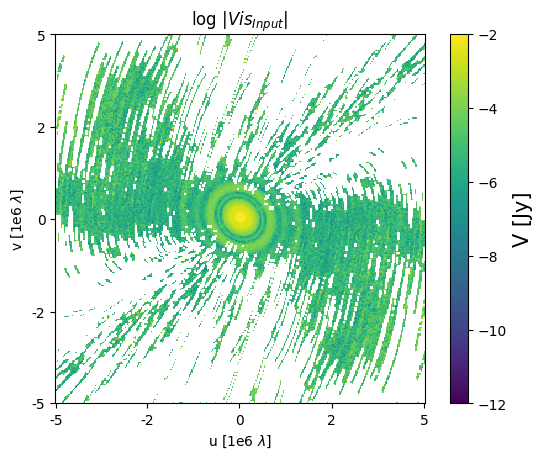

In [146]:
plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded.reshape(frank2d_._FT._Nx, frank2d_._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$|')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

In [173]:
sol = frank2d_.frank1d(u, v, Vis, Weights)

In [174]:
vis_f1d = frank2d_._frank1d_guess

In [175]:
size = [frank2d_._FT._Nx, frank2d_._FT._Ny]

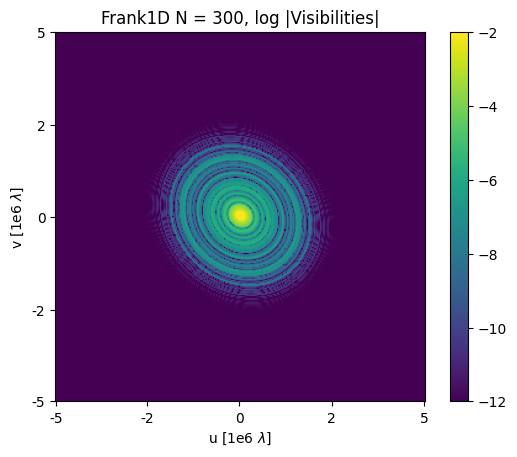

In [176]:
plt.imshow(np.log(np.abs(np.fft.fftshift(vis_f1d.reshape(size[0], size[1])))), origin='lower', vmin=-12, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(F'Frank1D N = {N}, log |Visibilities|')
plt.colorbar()

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_35182/3138845856.py:2: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(np.fft.fftshift((vis_gridded).reshape(size[0], size[1])))), origin='lower', vmin=-12, vmax=-2, alpha=1)


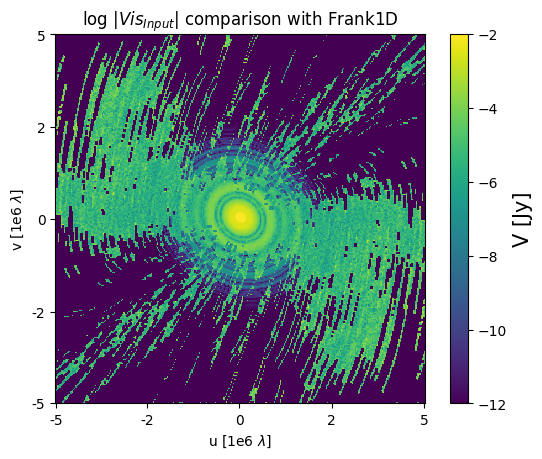

In [177]:
plt.imshow(np.log(np.abs(np.fft.fftshift((vis_f1d).reshape(size[0], size[1])))), origin='lower', vmin=-12, vmax=-2)
plt.imshow(np.log(np.abs(np.fft.fftshift((vis_gridded).reshape(size[0], size[1])))), origin='lower', vmin=-12, vmax=-2, alpha=1)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$| comparison with Frank1D')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

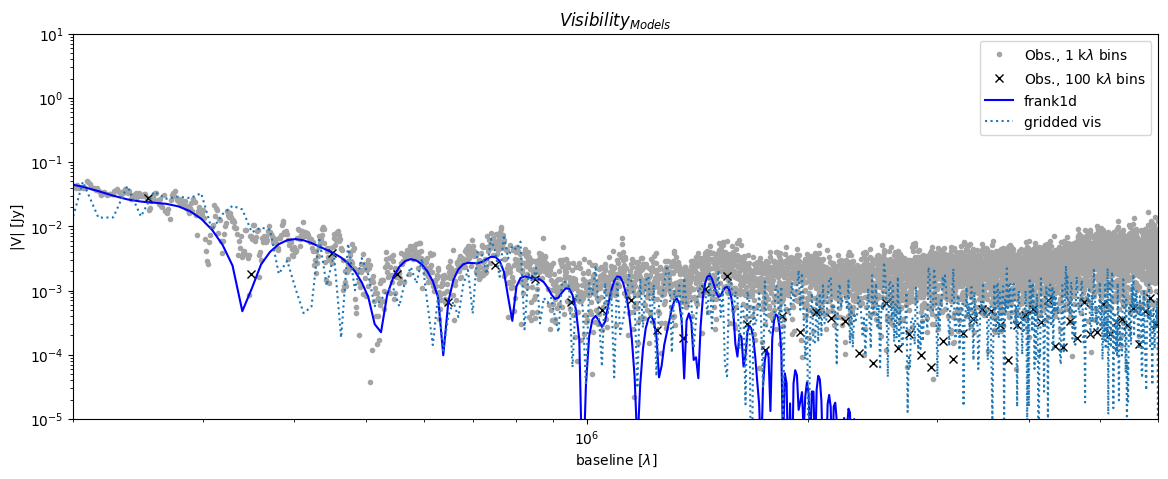

In [178]:
#  Plot variables.
cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
bin_widths = [1e3, 1e5]
baselines = np.hypot(u_deproj, v_deproj)         
grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                           np.log10(max(baselines.max(), baselines[-1])),
                           10**4)


plt.figure(figsize=(14,5))
# ---------------------------------------------------------------------------------------------
# Raw visibilities
binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[0])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[0],
             marker=ms[0], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[1])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[1],
             marker=ms[1], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


# -------------------------- BINS----------------------------------------------------------
#frank1d
Nbins = 1000
baselines_edges = np.linspace(sol.q[0], sol.q[-1], Nbins + 1 )
baselines_centers = np.sqrt(baselines_edges[:-1] * baselines_edges[1:]) 
range = (sol.q[0], sol.q[-1])

vis_fit_1d = sol.predict_deprojected(baselines_centers)
plt.plot(baselines_centers, np.abs(vis_fit_1d), color = "blue", label = r'frank1d')

# ---------------------------------------------------------------------------------------------
# gridded vis
q, Vis_d = get_vis_profile_deprojected(frank2d_, baselines_edges, range, weighted = False, goal = 'input')
plt.plot(baselines_centers, np.abs(Vis_d), label = f'gridded vis',ls=':')


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-5, 10)
plt.xlim(2e5, 6e6)
plt.ylabel('|V| [Jy]', size = 10)
plt.title(r'$Visibility_{Models}$ ')
plt.legend(fontsize= 10, loc = 'best')
plt.show()

### Running F2D

In [196]:
N = 300
m, c, l = -0.33, -0.1, 1.5e5

### Frank2D

#### Initially non deprojected

In [197]:
start_time = time.time()

#####
frank2d2 = Frank2D(N, Rout, Geometry(inc, pa, dra, ddec))
frank2d2.set_kernel('Wendland', [m, c, l])
frank2d2.fit(u, v, Vis, Weights, method = 'bicgstab', rtol = 1e-15, frank1d_guess = False)

#####
print("--------------------------------------")
end_time = time.time()
execution_time = end_time - start_time
print(f'time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')

Setting kernel: Wendland...
Gridding...
  --> time = 0.14  min |  8.17 seconds
Setting gridded data...
Setting fit with bicgstab ...
Setting guess... Visibilities gridded
Fitting...
  *  Constructing linear operators...
Setting A...
Setting A_precond...
Setting b...
     --> time = 5.56  min |  333.57 seconds
  *  Solving linear system...
     * BICGSTAB
         * rtol: 1e-15
         * final tolerance: 3.809599433470843e-09
         * maxiter:  900000
             .. iteration:  0
             .. iteration:  1
             .. iteration:  2
             .. iteration:  3
             .. iteration:  4
             .. iteration:  5
             .. iteration:  6
             .. iteration:  7
             .. iteration:  8
             .. iteration:  9
             .. iteration:  10
             .. iteration:  11
             .. iteration:  12
             .. iteration:  13
             .. iteration:  14
             .. iteration:  15
             .. iteration:  16
             .. iteration

In [198]:
u_2, v_2 = frank2d2._gridded_data['u'], frank2d2._gridded_data['v']
vis_sol2 = frank2d2.sol_visibility

u_2, v_2 = np.fft.fftshift(u_2.reshape(N, N)), np.fft.fftshift(v_2.reshape(N, N))
vis_sol2 = np.fft.fftshift(vis_sol2.reshape(N, N))

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_35182/48842606.py:1: RuntimeWarning: divide by zero encountered in log
  plt.pcolormesh(v_2, u_2, np.log(np.abs(vis_sol2)), cmap="viridis", vmin=-12, vmax=-2)


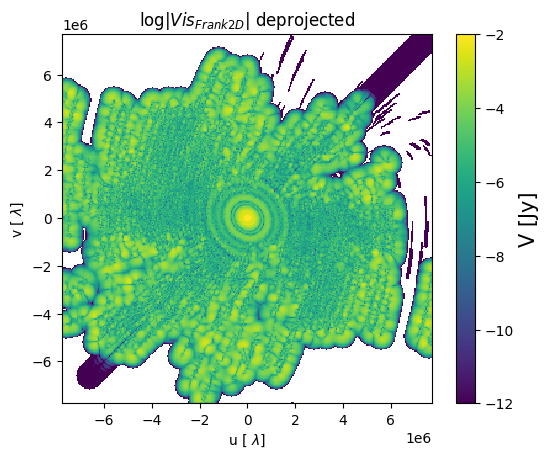

In [199]:
plt.pcolormesh(v_2, u_2, np.log(np.abs(vis_sol2)), cmap="viridis", vmin=-12, vmax=-2)
plt.xlabel(r'u [ $\lambda$]')
plt.ylabel(r'v [ $\lambda$]')
plt.gca().set_aspect('equal') 
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)
plt.title(r'log|$Vis_{Frank2D}$| deprojected')
plt.show()

In [200]:
frank2d2.fft()

Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds


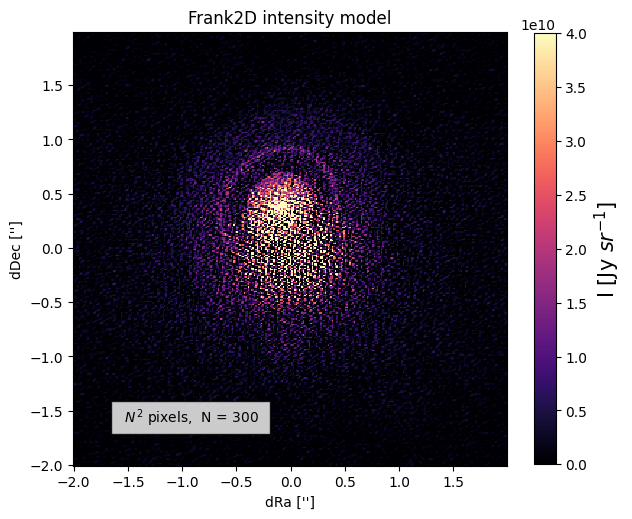

In [206]:
Plot(frank2d2, Geometry(inc, pa, dra, ddec)).intensity_model()

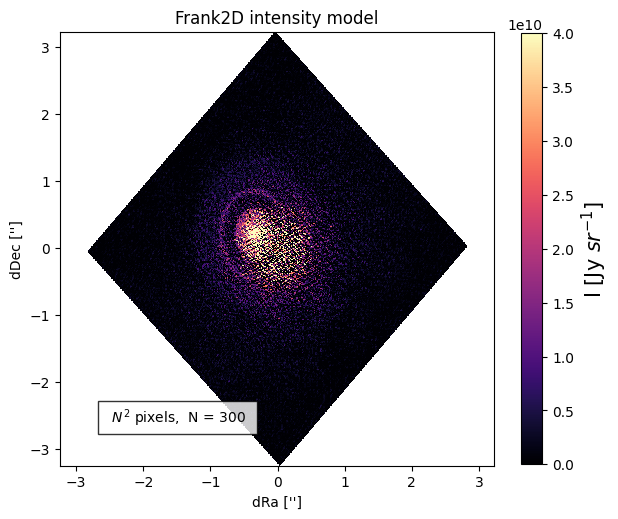

In [208]:
Plot(frank2d2, Geometry(inc, pa, dra, ddec)).intensity_model( deproject = True)

### Initially deprojected

In [203]:
start_time = time.time()

#####
frank2d2_deproj = Frank2D(N, Rout, Geometry(inc, pa, dra, ddec, deproject = True))
frank2d2_deproj.set_kernel('Wendland', [m, c, l])
frank2d2_deproj.fit(u, v, Vis, Weights, method = 'bicgstab', rtol = 1e-15, frank1d_guess = False)

#####
print("--------------------------------------")
end_time = time.time()
execution_time = end_time - start_time
print(f'time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')

Setting kernel: Wendland...
Gridding...
Deprojecting...
  --> time = 0.27  min |  16.00 seconds
Setting gridded data...
Setting fit with bicgstab ...
Setting guess... Visibilities gridded
Fitting...
  *  Constructing linear operators...
Setting A...
Setting A_precond...
Setting b...
     --> time = 8.00  min |  479.83 seconds
  *  Solving linear system...
     * BICGSTAB
         * rtol: 1e-15
         * final tolerance: 9.620304489255773e-09
         * maxiter:  900000
             .. iteration:  0
             .. iteration:  1
             .. iteration:  2
             .. iteration:  3
             .. iteration:  4
             .. iteration:  5
             .. iteration:  6
             .. iteration:  7
             .. iteration:  8
             .. iteration:  9
             .. iteration:  10
             .. iteration:  11
             .. iteration:  12
             .. iteration:  13
             .. iteration:  14
             .. iteration:  15
             .. iteration:  16
        

In [204]:
u_2_deproj, v_2_deproj = frank2d2_deproj._gridded_data['u'], frank2d2_deproj._gridded_data['v']
vis_sol2_deproj = frank2d2_deproj.sol_visibility

u_2_deproj, v_2_deproj = np.fft.fftshift(u_2_deproj.reshape(N, N)), np.fft.fftshift(v_2_deproj.reshape(N, N))
vis_sol2_deproj = np.fft.fftshift(vis_sol2_deproj.reshape(N, N))

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_35182/3887567771.py:1: RuntimeWarning: divide by zero encountered in log
  plt.pcolormesh(v_2_deproj, u_2_deproj, np.log(np.abs(vis_sol2_deproj)), cmap="viridis", vmin=-12, vmax=-2)


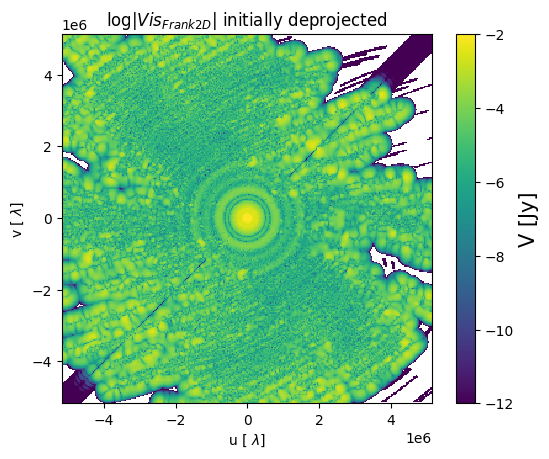

In [48]:
plt.pcolormesh(v_2_deproj, u_2_deproj, np.log(np.abs(vis_sol2_deproj)), cmap="viridis", vmin=-12, vmax=-2)
plt.xlabel(r'u [ $\lambda$]')
plt.ylabel(r'v [ $\lambda$]')
plt.gca().set_aspect('equal') 
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)
plt.title(r'log|$Vis_{Frank2D}$| initially deprojected')
plt.show()

In [49]:
frank2d2_deproj.fft()

Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds


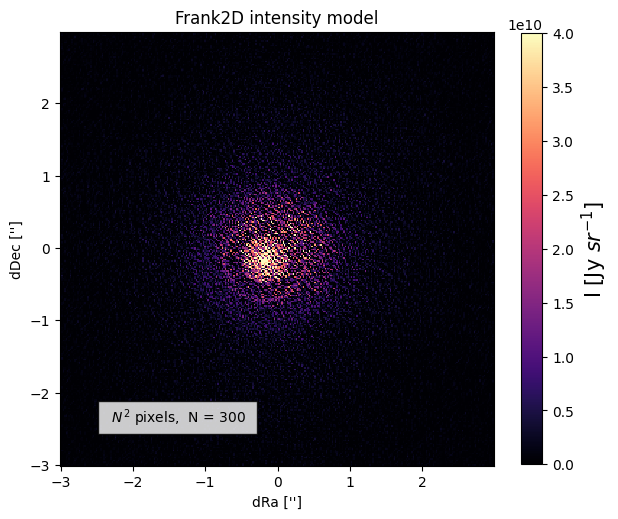

In [52]:
Plot(frank2d2_deproj, Geometry(inc, pa, dra, ddec)).intensity_model()

## Comparison with f1d

In [169]:
# Frank 1D Parameters
n_pts = 350
alpha = 1.3
w_smooth = 1e-4

geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
FF = FrankFitter(Rout, n_pts, geom, alpha = alpha, weights_smooth = w_smooth)
sol = FF.fit(u, v, Vis, Weights)

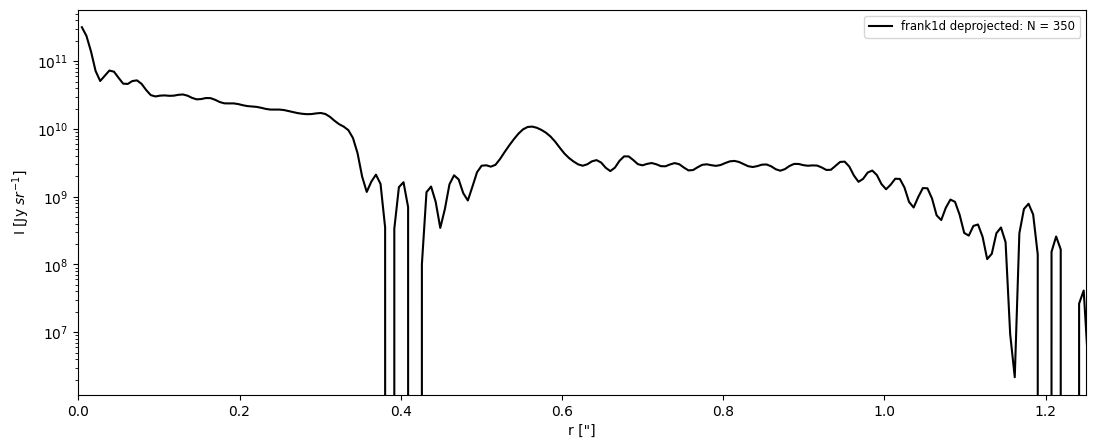

In [172]:
plt.figure(figsize=(13,5))
plt.plot(sol.r, sol.mean, 'black',label =f'frank1d deprojected: N = {n_pts}')
plt.xlabel('r ["]')
plt.xlim(0,1.25)      
#plt.ylim(3e7, 1e11)
plt.ylabel(r'I [Jy $sr^{-1}$]')
plt.legend(fontsize = 'small')
#plt.title('Comparison N = '+ str(N))
plt.yscale("log")
plt.show()

### Fourier space

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_35182/37162066.py:67: RuntimeWarning: invalid value encountered in divide
  return q_centers, Vis_Weights_binned/Weights_binned
/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_35182/37162066.py:25: RuntimeWarning: invalid value encountered in divide
  return q_centers, Vis_Weights_binned/Weights_binned


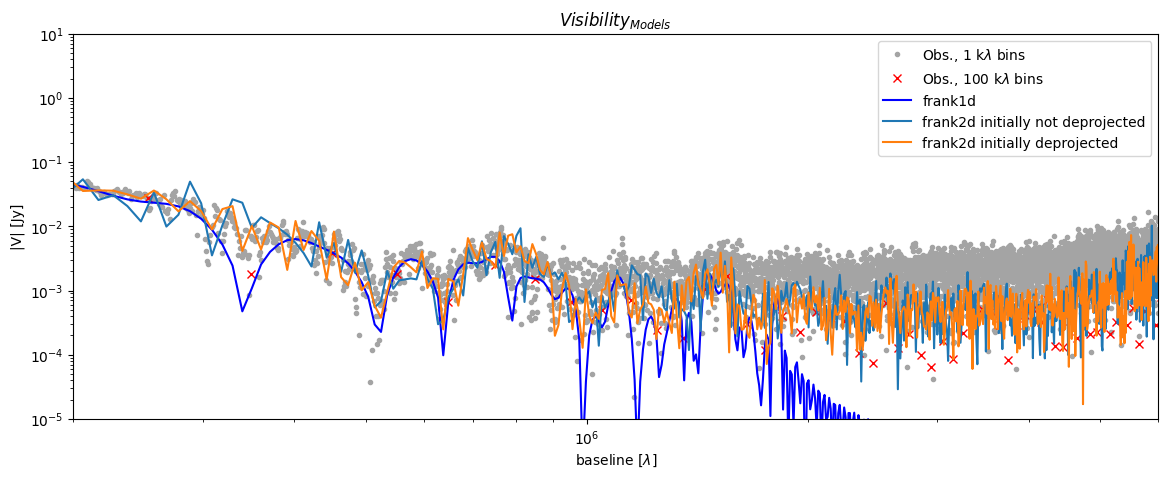

In [55]:
#  Plot variables.
cs, ms = ['#a4a4a4', 'red'], ['.', 'x']
bin_widths = [1e3, 1e5]
baselines = np.hypot(u_deproj, v_deproj)         
grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                           np.log10(max(baselines.max(), baselines[-1])),
                           10**4)


plt.figure(figsize=(14,5))
# ---------------------------------------------------------------------------------------------
# Raw visibilities
binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[0])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[0],
             marker=ms[0], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[1])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[1],
             marker=ms[1], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


# -------------------------- BINS----------------------------------------------------------
#frank1d
Nbins = 1000
baselines_edges = np.linspace(sol.q[0], sol.q[-1], Nbins + 1 )
baselines_centers = np.sqrt(baselines_edges[:-1] * baselines_edges[1:]) 
range = (sol.q[0], sol.q[-1])

vis_fit_1d = sol.predict_deprojected(baselines_centers)
plt.plot(baselines_centers, np.abs(vis_fit_1d), color = "blue", label = r'frank1d')

# ---------------------------------------------------------------------------------------------
# frank2d initially not deprojected
q, Vis_ = get_vis_profile_deprojected(frank2d2, baselines_edges, range, weighted = True, goal = 'model')
plt.plot(baselines_centers, np.abs(Vis_), label = f'frank2d initially not deprojected',ls='-')

# ---------------------------------------------------------------------------------------------
# frank2d initially  deprojected
q, Vis_deproj = get_vis_profile(frank2d2_deproj, baselines_edges, range, weighted = True)
plt.plot(baselines_centers, np.abs(Vis_deproj), label = f'frank2d initially deprojected',ls='-')



plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-5, 10)
plt.xlim(2e5, 6e6)
plt.ylabel('|V| [Jy]', size = 10)
plt.title(r'$Visibility_{Models}$ ')
plt.legend(fontsize= 10, loc = 'best')
plt.show()

### Image space

In [57]:
cos_i =  np.cos(frank2d2._Geometry._inc*deg_to_rad)

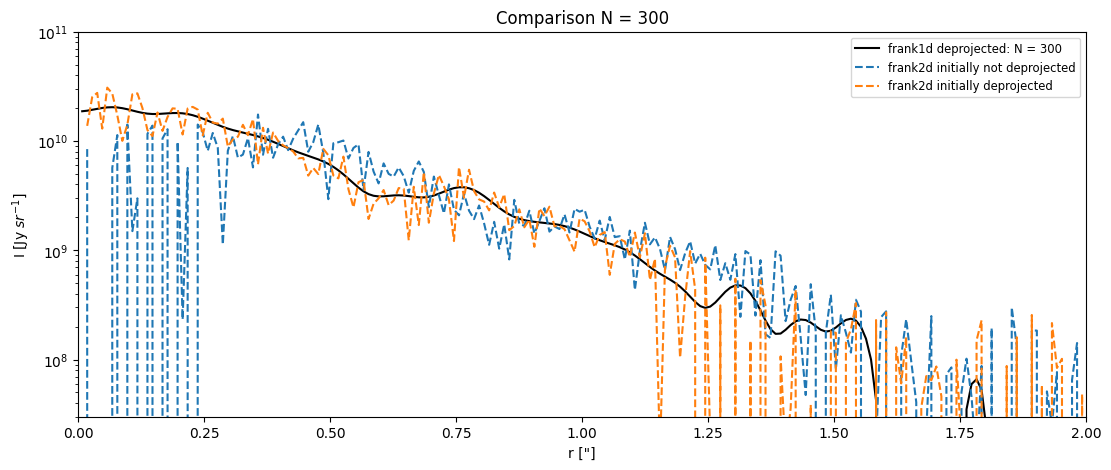

In [60]:
plt.figure(figsize=(13,5))
plt.plot(sol.r, sol.mean, 'black',label =f'frank1d deprojected: N = {n_pts}')

dr = (sol.r[1] - sol.r[0])/2
bin_edges = np.concatenate((sol.r - dr, [sol.r[-1] + dr]))

r_f2d_projected_d, I_f2d_projected_d = get_radial_profile_deprojected(frank2d2, bin_edges, (sol.r[0], sol.r[-1]))
plt.plot(sol.r, I_f2d_projected_d, label = r'frank2d initially not deprojected', ls='--')

r_f2d_deprojected, I_f2d_deprojected = get_radial_profile(frank2d2_deproj, bin_edges, (sol.r[0], sol.r[-1]))
plt.plot(sol.r, I_f2d_deprojected/cos_i, label = r'frank2d initially deprojected', ls='--')

plt.xlabel('r ["]')
plt.xlim(0,2)      
plt.ylim(3e7, 1e11)
plt.ylabel(r'I [Jy $sr^{-1}$]')
plt.legend(fontsize = 'small')
plt.title('Comparison N = '+ str(N))
plt.yscale("log")
plt.show()